# Trabalho Prático: Correlação de Astrous

Alunos: Adriel Ferreira & Kamily Assis

Características:
- leitura de parâmetros via json
- validação de parâmetros
- leitura da Imagem
- separação em canais RGB
- aplicação de filtro em correlação dilatada
- comparação com funções prontas


A fazer:

- separar testes (SEM PADDING)
    - Gaussiano 5x5 (feito)
    - Box 1x10 
    - Box 10x1 
    - Box 10x10
    - Sobel Horizontal e Vertical


## 1. Bibliotecas

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import json
import os

## 2. Visualização

In [2]:
def show_image(img, title=None, cmap=None):
    plt.figure(figsize=(5,5))
    plt.imshow(img, cmap=cmap)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

In [3]:
def exibir_canais_rgb(r_color, g_color, b_color, rgb_array):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 4, 1)
    plt.imshow(rgb_array)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(r_color)
    plt.title("Canal R")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(g_color)
    plt.title("Canal G")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(b_color)
    plt.title("Canal B")
    plt.axis("off")

    plt.show()

In [4]:
def mostrar_parametros(stride: int, dilatacao: int, dimensoes: list, filtro: np.array, ativacao: str):
    print("Parâmetros lidos:")
    print(f"Stride: {stride}")
    print(f"Dilatação: {dilatacao}")
    print(f"Dimensões do filtro: {dimensoes}")
    print(f"Filtro:\n{filtro}")
    print(f"Ativação: {ativacao}")

## 3. Imagem

In [5]:
def carregar_imagem(path):
    img = Image.open(path)
    return np.array(img)

def separar_canais_rgb(img):
    r = img[:,:,0]
    g = img[:,:,1]
    b = img[:,:,2]
    return r,g,b

In [6]:
def salvar_imagem(filepath: str, img_array: np.ndarray, usar_cv2: bool = False):
    pasta = os.path.dirname(filepath)
    if pasta:
        os.makedirs(pasta, exist_ok=True)

    img = np.clip(img_array, 0, 255).astype(np.uint8)

    if usar_cv2:
        if img.ndim == 3 and img.shape[2] == 3:
            img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
        sucesso = cv2.imwrite(filepath, img)
        if not sucesso:
            raise IOError(f"Não foi possível salvar a imagem em: {filepath}")
    else:
        Image.fromarray(img).save(filepath)

    print(f"Imagem salva em: {filepath}")

## 4. Leitura e Validação de Parâmetros (JSON)

In [7]:
def validar_parametros(params):
    assert 'stride' in params
    assert 'dilatacao' in params
    assert 'filtro' in params

    stride = int(params['stride'])
    dilatacao = int(params['dilatacao'])
    filtro = np.array(params['filtro'], dtype=np.float32)
    ativacao = params.get('ativacao', None)

    assert stride > 0
    assert dilatacao > 0
    assert filtro.ndim == 2

    return stride, dilatacao, filtro, ativacao


def ler_parametros_json(filepath: str):
    
    with open(filepath, 'r') as file:
        parametros = json.load(file)
    
    stride = parametros.get("stride")
    dilatacao = parametros.get("dilatacao")
    dimensoes = parametros.get("dimensoes")
    filtro = np.array(parametros.get("filtro"))
    ativacao = parametros.get("ativacao")
    
    return stride, dilatacao, dimensoes, filtro, ativacao

## 5. Correlação Atrous

In [8]:
def correlacao_atrous(nome_canal, canal, filtro, dilatacao, stride, ativacao):

    altura_img, largura_img = canal.shape
    altura_filtro, largura_filtro = filtro.shape

    altura_filtro_dilat = (altura_filtro - 1) * dilatacao + 1
    largura_filtro_dilat = (largura_filtro - 1) * dilatacao + 1

    altura_out = (altura_img - altura_filtro_dilat) // stride + 1
    largura_out = (largura_img - largura_filtro_dilat) // stride + 1

    saida = np.zeros((altura_out, largura_out), dtype=np.float32)

    for i in range(0, altura_img - altura_filtro_dilat + 1, stride):
        for j in range(0, largura_img - largura_filtro_dilat + 1, stride):

            soma = 0.0

            for ki in range(altura_filtro):
                for kj in range(largura_filtro):
                    pos_i = i + ki * dilatacao
                    pos_j = j + kj * dilatacao
                    soma += canal[pos_i,pos_j] * filtro[ki,kj]

            out_i = i // stride
            out_j = j // stride

            saida[out_i,out_j] = soma

    if ativacao == 'relu':
        saida = np.maximum(0,saida)

    return saida

In [24]:
## Seria bom dar uma limpadinha

def normalizar_filtro_se_necessario(filtro: np.ndarray) -> np.ndarray:
    filtro_float = filtro.astype(np.float32)
    soma_filtro = float(np.sum(filtro_float))

    if soma_filtro > 0 and not np.isclose(soma_filtro, 1.0):
        return filtro_float / soma_filtro
        
    return filtro_float

def colorir_canais(r, g, b):
    r_color = np.stack([r, np.zeros_like(r), np.zeros_like(r)], axis=2)
    g_color = np.stack([np.zeros_like(g), g, np.zeros_like(g)], axis=2)
    b_color = np.stack([np.zeros_like(b), np.zeros_like(b), b], axis=2)
    return r_color, g_color, b_color


def rgb_float_para_uint8(imagem_rgb_float: np.ndarray) -> np.ndarray:
    min_val = float(np.min(imagem_rgb_float))
    max_val = float(np.max(imagem_rgb_float))

    if min_val < 0.0 or max_val > 255.0:
        print(f"Reescalando imagem final para evitar saturação (min={min_val:.2f}, max={max_val:.2f})")
        if np.isclose(max_val, min_val):
            return np.zeros_like(imagem_rgb_float, dtype=np.uint8)

        imagem_norm = (imagem_rgb_float - min_val) / (max_val - min_val)
        return (imagem_norm * 255.0).astype(np.uint8)

    return np.clip(imagem_rgb_float, 0, 255).astype(np.uint8)

def processar_imagem_rgb(r: np.ndarray, g: np.ndarray, b: np.ndarray,
                        stride: int, dilatacao: int, filtro: np.ndarray, ativacao: str):

    filtro_proc = normalizar_filtro_se_necessario(filtro)

    r_out = correlacao_atrous("R", r, filtro_proc, dilatacao, stride, ativacao)
    g_out = correlacao_atrous("G", g, filtro_proc, dilatacao, stride, ativacao)
    b_out = correlacao_atrous("B", b, filtro_proc, dilatacao, stride, ativacao)

    imagem_float = np.stack([r_out, g_out, b_out], axis=2).astype(np.float32)
    imagem_u8 = rgb_float_para_uint8(imagem_float)

    r_u8,g_u8,b_u8 = separar_canais_rgb(imagem_u8)

    r_color, g_color, b_color = colorir_canais(r_u8, g_u8, b_u8)

    exibir_canais_rgb(r_color, g_color, b_color, imagem_u8)

    return imagem_u8

## 6. Funções de Comparação Manual vs OpenCV 

In [35]:
def aplicar_filtro_opencv_sem_padding(img: np.ndarray, filtro: np.ndarray) -> np.ndarray:
    kernel = filtro.astype(np.float32) / filtro.sum()
    pad_h = filtro.shape[0] // 2
    pad_w = filtro.shape[1] // 2

    img_filtrada = cv2.filter2D(img.astype(np.float32), -1, kernel, borderType=cv2.BORDER_CONSTANT)

    h, w = img_filtrada.shape[:2]
    crop = img_filtrada[
        pad_h : h - pad_h if pad_h > 0 else h,
        pad_w : w - pad_w if pad_w > 0 else w
    ]

    return np.clip(crop, 0, 255).astype(np.uint8)

def visualizar_comparacao(img_manual, img_opencv_nop, nome_filtro: str):
    imagens = [
        (img_manual,     f"Manual - {nome_filtro}\n Dimensões: {img_manual.shape}"),
        (img_opencv_nop, f"OpenCV - {nome_filtro} (sem padding)\n Dimensões: {img_opencv_nop.shape}"),
    ]

    fig, axs = plt.subplots(1, 2, figsize=(14, 6))
    for ax, (img, titulo) in zip(axs, imagens):
        ax.imshow(img)
        ax.set_title(titulo)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

## 7. Testes (Execução)

### Base

In [25]:
# carregar imagem
img_colorida = carregar_imagem("Imagens/testpat.tif")
img_pb = carregar_imagem("Imagens/Shapes.png")

img = img_pb

# separar canais
r,g,b = separar_canais_rgb(img)

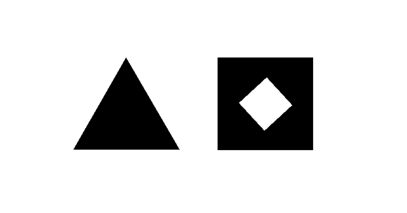

In [26]:
show_image(img)

### Gaussiano 5x5

Parâmetros lidos:
Stride: 1
Dilatação: 1
Dimensões do filtro: [5, 5]
Filtro:
[[ 1  4  6  4  1]
 [ 4 16 24 16  4]
 [ 6 24 36 24  6]
 [ 4 16 24 16  4]
 [ 1  4  6  4  1]]
Ativação: relu


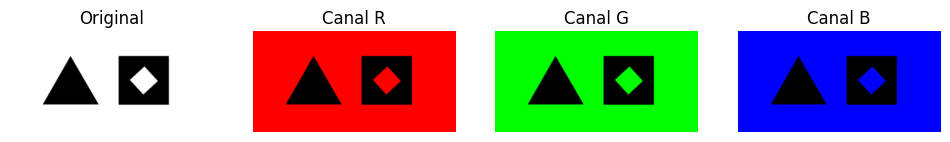

Imagem salva em: resultados/gaussiano_manual.jpg


In [ ]:
params_path = "parametros/gaussiano5_5.json"
nome_filtro = os.path.splitext(os.path.basename(params_path))[0]

stride, dilatacao, dims, filtro_gauss5_5, ativacao = ler_parametros_json(params_path)
mostrar_parametros(stride, dilatacao, dims, filtro_gauss5_5, ativacao)

imagem_resultante = processar_imagem_rgb(r, g, b, stride, dilatacao, filtro_gauss5_5, ativacao)

os.makedirs("resultados", exist_ok=True)
salvar_imagem(f"resultados/{nome_filtro}_manual.jpg", imagem_resultante)

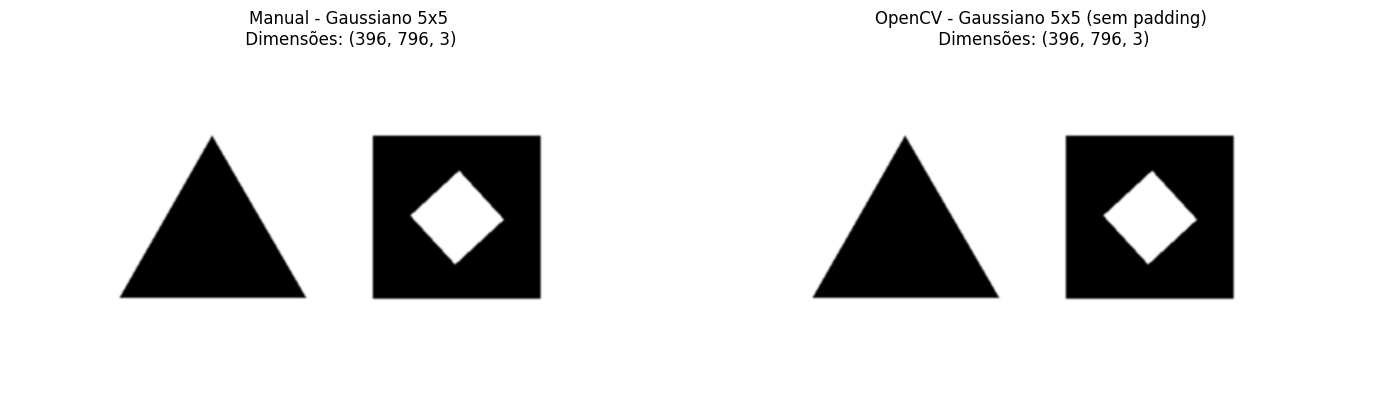

In [28]:
# Comparação - Manual vs OpenCV (sem padding)
imagem_resultante_opencv_nop = aplicar_filtro_opencv_sem_padding(img, filtro_gauss5_5)

visualizar_comparacao(imagem_resultante, imagem_resultante_opencv_nop, "Gaussiano 5x5")

### Box 1x10

Parâmetros lidos:
Stride: 1
Dilatação: 1
Dimensões do filtro: [1, 10]
Filtro:
[[1 1 1 1 1 1 1 1 1 1]]
Ativação: relu


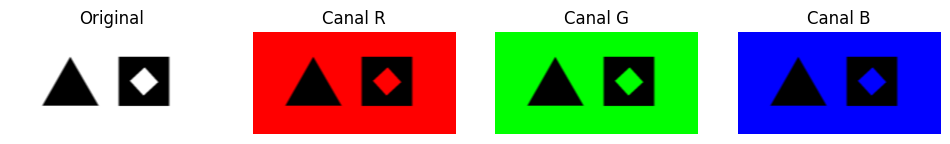

Imagem salva em: resultados/box_1_10_manual.jpg


In [33]:
params_path = "parametros/box_1_10.json"
nome_filtro = os.path.splitext(os.path.basename(params_path))[0]

stride, dilatacao, dims, filtro, ativacao = ler_parametros_json(params_path)
mostrar_parametros(stride, dilatacao, dims, filtro, ativacao)

imagem_resultante = processar_imagem_rgb(r, g, b, stride, dilatacao, filtro, ativacao)

os.makedirs("resultados", exist_ok=True)
salvar_imagem(f"resultados/{nome_filtro}_manual.jpg", imagem_resultante)



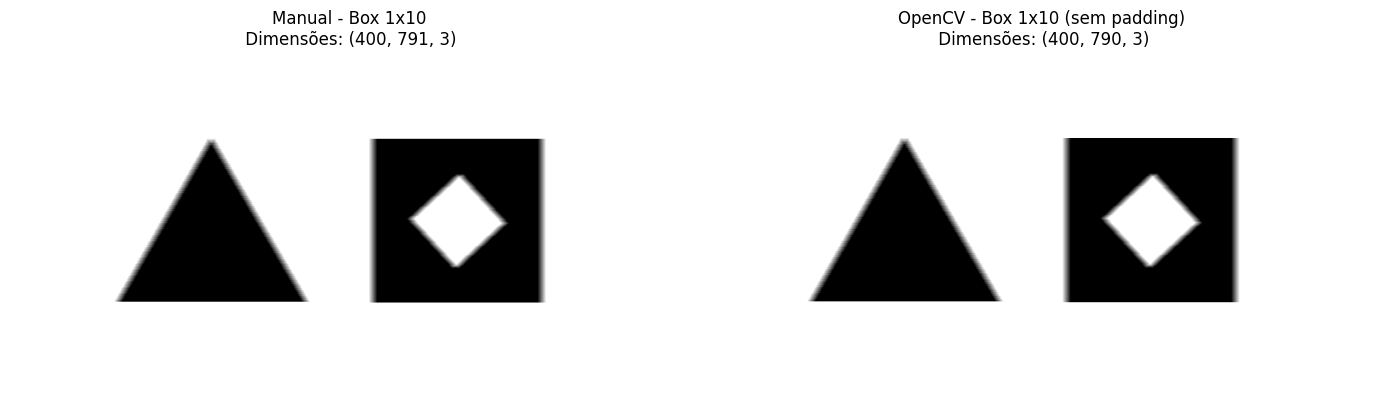

In [36]:
# Comparação - Manual vs OpenCV (sem padding)
imagem_resultante_opencv_nop = aplicar_filtro_opencv_sem_padding(img, filtro)

visualizar_comparacao(imagem_resultante, imagem_resultante_opencv_nop, "Box 1x10")